In [1]:
# Imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
# Load data and create scenario groups
DATA_PATH = r'C:\\Users\\manur\\OneDrive\\Documents\\Multi_Crop_Ranking_\\Multi_Crop_Ranking\\Notebooks\\Models\\Crop_training_data_FULL_F1.csv'
df = pd.read_csv(DATA_PATH)

ENV_COLS = [
    'temperature', 'rainfall', 'sunshine_hours',
    'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code'
]
rounded = df[ENV_COLS].round(2)
df['scenario_id'] = pd.util.hash_pandas_object(rounded, index=False).astype('int64')

In [3]:
# Prepare features and target
y = df['suitability_class'].map({'Suitable': 1, 'Unsuitable': 0}).astype(int)
DROP_COLS = ['suitability_class', 'suitability', 'texture', 'rooting_depth_m']
X = df.drop(columns=DROP_COLS)
groups = df['scenario_id']

categorical_cols = ['crop']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

In [4]:
# Train/test split by scenario
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train scenarios: {g_train.nunique()}, Test scenarios: {g_test.nunique()}')

Train: (1680, 11), Test: (420, 11)
Train scenarios: 1680, Test scenarios: 420


In [5]:
# Define preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

In [6]:
# Baseline Logistic Regression
baseline_pipe = Pipeline([
    ('preprocess', clone(preprocessor)),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

baseline_pipe.fit(X_train, y_train)

baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_proba >= 0.5).astype(int)

baseline_roc = roc_auc_score(y_test, baseline_proba)
baseline_pr = average_precision_score(y_test, baseline_proba)

print("=== Baseline Logistic Regression ===")
print(f"ROC-AUC: {baseline_roc:.4f}")
print(f"PR-AUC:  {baseline_pr:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, baseline_pred))
print("\nClassification Report:")
print(classification_report(y_test, baseline_pred, digits=3))

=== Baseline Logistic Regression ===
ROC-AUC: 0.9133
PR-AUC:  0.9425

Confusion Matrix:
[[131  43]
 [ 31 215]]

Classification Report:
              precision    recall  f1-score   support

           0      0.809     0.753     0.780       174
           1      0.833     0.874     0.853       246

    accuracy                          0.824       420
   macro avg      0.821     0.813     0.816       420
weighted avg      0.823     0.824     0.823       420



In [7]:
# Expanded hyperparameter tuning with GridSearchCV
pipe = Pipeline(steps=[('preprocess', preprocessor),
                       ('model', LogisticRegression(max_iter=2000, random_state=42))])

# Expanded parameter grid – you can adjust ranges based on your resources
param_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'model__class_weight': [None, 'balanced'],
    'model__penalty': ['l2'],               # can also add 'l1' with solver='liblinear' or 'saga'
    'model__solver': ['lbfgs', 'liblinear'] # lbfgs works with l2; liblinear works with l1 and l2
}

cv = GroupKFold(n_splits=5)
gs = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train, groups=g_train)

print("\nBest CV ROC-AUC: {:.4f}".format(gs.best_score_))
print("Best parameters:")
print(gs.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV ROC-AUC: 0.9128
Best parameters:
{'model__C': 10.0, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


c:\Users\manur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [8]:
# Evaluate tuned model on test set
best_model = gs.best_estimator_
tuned_proba = best_model.predict_proba(X_test)[:, 1]
tuned_pred = (tuned_proba >= 0.5).astype(int)

tuned_roc = roc_auc_score(y_test, tuned_proba)
tuned_pr = average_precision_score(y_test, tuned_proba)

print("=== Tuned Logistic Regression ===")
print(f"ROC-AUC: {tuned_roc:.4f}")
print(f"PR-AUC:  {tuned_pr:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))
print("\nClassification Report:")
print(classification_report(y_test, tuned_pred, digits=3))

=== Tuned Logistic Regression ===
ROC-AUC: 0.9138
PR-AUC:  0.9429

Confusion Matrix:
[[134  40]
 [ 32 214]]

Classification Report:
              precision    recall  f1-score   support

           0      0.807     0.770     0.788       174
           1      0.843     0.870     0.856       246

    accuracy                          0.829       420
   macro avg      0.825     0.820     0.822       420
weighted avg      0.828     0.829     0.828       420



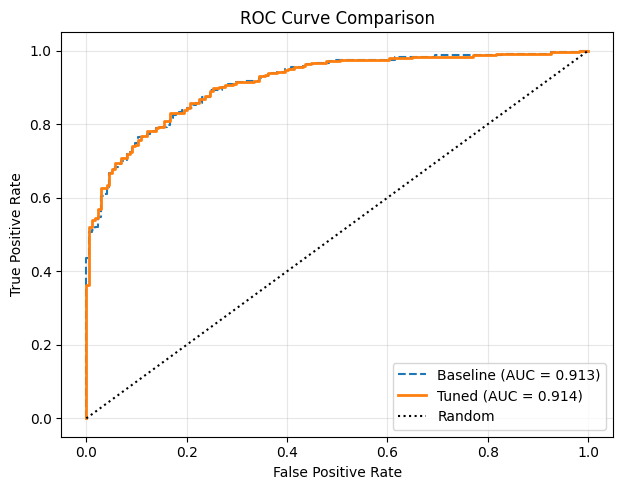

In [9]:
# Comparison plots (Baseline vs Tuned)
# ROC curves
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_proba)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {baseline_roc:.3f})', linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC = {tuned_roc:.3f})', linewidth=2)
plt.plot([0,1],[0,1], 'k:', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

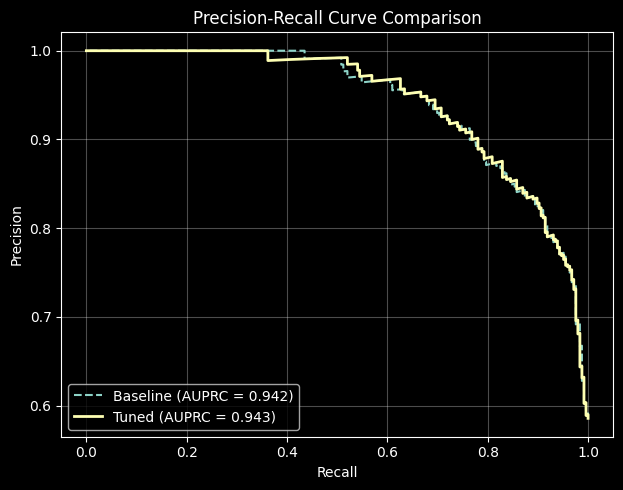

In [16]:
# PR curves
prec_base, rec_base, _ = precision_recall_curve(y_test, baseline_proba)
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, tuned_proba)
pr_auc_base = auc(rec_base, prec_base)
pr_auc_tuned = auc(rec_tuned, prec_tuned)

plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
plt.plot(rec_base, prec_base, label=f'Baseline (AUPRC = {pr_auc_base:.3f})', linestyle='--')
plt.plot(rec_tuned, prec_tuned, label=f'Tuned (AUPRC = {pr_auc_tuned:.3f})', linewidth=2)
plt.style.use('dark_background')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision‑Recall Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

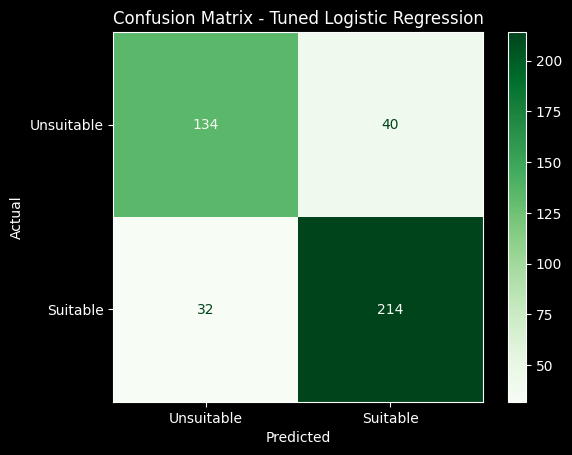

In [15]:
# Confusion Matrix
tuned_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, tuned_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Unsuitable', 'Suitable'])
disp.plot(cmap='Greens', values_format='d')
plt.style.use('dark_background')
disp.ax_.set_xlabel('Predicted')
disp.ax_.set_ylabel('Actual')
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.show()

In [12]:
# Save models
joblib.dump(baseline_pipe, 'baseline_logreg.pkl')
joblib.dump(best_model, 'tuned_logreg.pkl')

['tuned_logreg.pkl']